In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fivethirtyeight/fivethirtyeight-comic-characters-dataset/marvel-wikia-data.csv
/kaggle/input/datasets/fivethirtyeight/fivethirtyeight-comic-characters-dataset/README.md
/kaggle/input/datasets/fivethirtyeight/fivethirtyeight-comic-characters-dataset/dc-wikia-data.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
marvel = pd.read_csv(
    "/kaggle/input/datasets/fivethirtyeight/fivethirtyeight-comic-characters-dataset/marvel-wikia-data.csv"
)

dc = pd.read_csv(
    "/kaggle/input/datasets/fivethirtyeight/fivethirtyeight-comic-characters-dataset/dc-wikia-data.csv"
)

In [4]:
marvel.head()

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,Aug-62,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,Mar-41,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,Oct-74,1974.0
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2961.0,Mar-63,1963.0
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,2258.0,Nov-50,1950.0


In [5]:
dc.head()

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,YEAR
0,1422,Batman (Bruce Wayne),\/wiki\/Batman_(Bruce_Wayne),Secret Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3093.0,"1939, May",1939.0
1,23387,Superman (Clark Kent),\/wiki\/Superman_(Clark_Kent),Secret Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2496.0,"1986, October",1986.0
2,1458,Green Lantern (Hal Jordan),\/wiki\/Green_Lantern_(Hal_Jordan),Secret Identity,Good Characters,Brown Eyes,Brown Hair,Male Characters,NaN,Living Characters,1565.0,"1959, October",1959.0
3,1659,James Gordon (New Earth),\/wiki\/James_Gordon_(New_Earth),Public Identity,Good Characters,Brown Eyes,White Hair,Male Characters,NaN,Living Characters,1316.0,"1987, February",1987.0
4,1576,Richard Grayson (New Earth),\/wiki\/Richard_Grayson_(New_Earth),Secret Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,1237.0,"1940, April",1940.0


In [6]:
marvel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16376 entries, 0 to 16375
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   page_id           16376 non-null  int64  
 1   name              16376 non-null  object 
 2   urlslug           16376 non-null  object 
 3   ID                12606 non-null  object 
 4   ALIGN             13564 non-null  object 
 5   EYE               6609 non-null   object 
 6   HAIR              12112 non-null  object 
 7   SEX               15522 non-null  object 
 8   GSM               90 non-null     object 
 9   ALIVE             16373 non-null  object 
 10  APPEARANCES       15280 non-null  float64
 11  FIRST APPEARANCE  15561 non-null  object 
 12  Year              15561 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 1.6+ MB


In [7]:
marvel["Publisher"] = "Marvel"
dc["Publisher"] = "DC"

characters = pd.concat([marvel, dc], ignore_index=True)

characters.head()

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year,Publisher,YEAR
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,Aug-62,1962.0,Marvel,NaN
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,Mar-41,1941.0,Marvel,NaN
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,Oct-74,1974.0,Marvel,NaN
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2961.0,Mar-63,1963.0,Marvel,NaN
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,2258.0,Nov-50,1950.0,Marvel,NaN


In [8]:
characters.shape

(23272, 15)

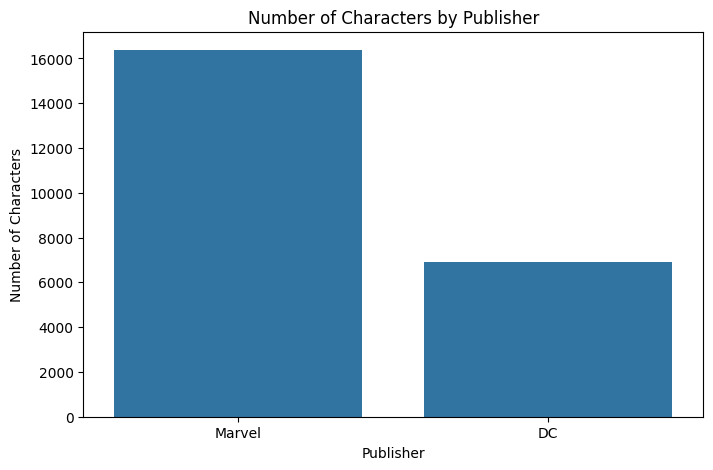

In [9]:
plt.figure(figsize=(8, 5))

sns.countplot(data=characters, x="Publisher")

plt.title("Number of Characters by Publisher")
plt.xlabel("Publisher")
plt.ylabel("Number of Characters")

plt.show()

In [10]:
characters.head()

,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year,Publisher,YEAR
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,Aug-62,1962.0,Marvel,NaN
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,Mar-41,1941.0,Marvel,NaN
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,Oct-74,1974.0,Marvel,NaN
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2961.0,Mar-63,1963.0,Marvel,NaN
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,2258.0,Nov-50,1950.0,Marvel,NaN


In [11]:
characters.columns

Index(['page_id', 'name', 'urlslug', 'ID', 'ALIGN', 'EYE', 'HAIR', 'SEX',
       'GSM', 'ALIVE', 'APPEARANCES', 'FIRST APPEARANCE', 'Year', 'Publisher',
       'YEAR'],
      dtype='object')

In [12]:
characters.dtypes

page_id               int64
name                 object
urlslug              object
ID                   object
ALIGN                object
EYE                  object
HAIR                 object
SEX                  object
GSM                  object
ALIVE                object
APPEARANCES         float64
FIRST APPEARANCE     object
Year                float64
Publisher            object
YEAR                float64
dtype: object

In [13]:
characters.isnull().sum()

page_id                 0
name                    0
urlslug                 0
ID                   5783
ALIGN                3413
EYE                 13395
HAIR                 6538
SEX                   979
GSM                 23118
ALIVE                   6
APPEARANCES          1451
FIRST APPEARANCE      884
Year                 7711
Publisher               0
YEAR                16445
dtype: int64

In [14]:
missing_values = characters.isnull().sum()

missing_percentage = (missing_values / len(characters)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary

,Missing Values,Percentage
page_id,0,0.000000
name,0,0.000000
urlslug,0,0.000000
ID,5783,24.849605
ALIGN,3413,14.665693
EYE,13395,57.558439
HAIR,6538,28.093847
SEX,979,4.206772
GSM,23118,99.338261
ALIVE,6,0.025782


In [15]:
characters.duplicated().sum()

np.int64(0)

In [16]:
marvel["Publisher"] = "Marvel"
dc["Publisher"] = "DC"

In [17]:
characters["Publisher"].value_counts()

Publisher
Marvel    16376
DC         6896
Name: count, dtype: int64

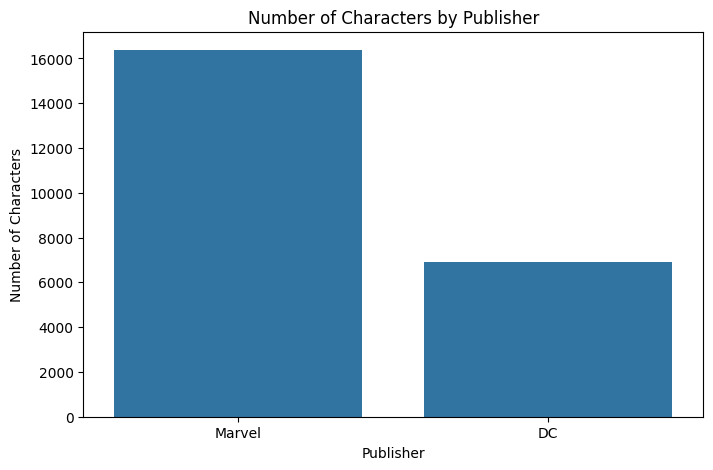

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(data=characters, x="Publisher")

plt.title("Number of Characters by Publisher")
plt.xlabel("Publisher")
plt.ylabel("Number of Characters")

plt.show()

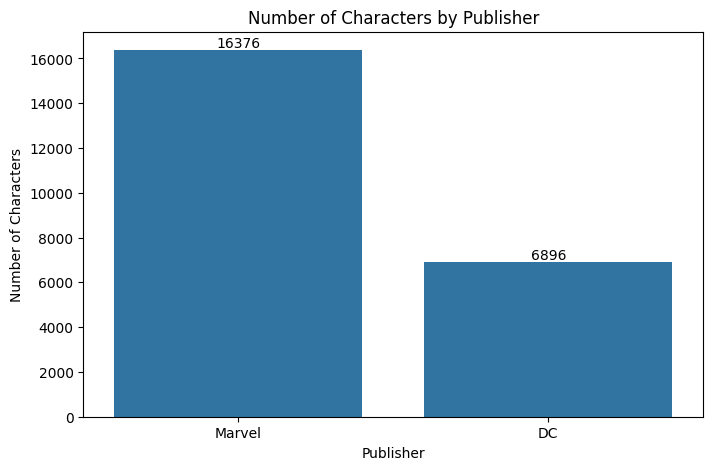

In [19]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=characters, x="Publisher")

plt.title("Number of Characters by Publisher")
plt.xlabel("Publisher")
plt.ylabel("Number of Characters")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Finding

The dataset contains more characters from Marvel than DC.

In [20]:
characters["SEX"].value_counts()

SEX
Male Characters           16421
Female Characters          5804
Agender Characters           45
Genderless Characters        20
Genderfluid Characters        2
Transgender Characters        1
Name: count, dtype: int64

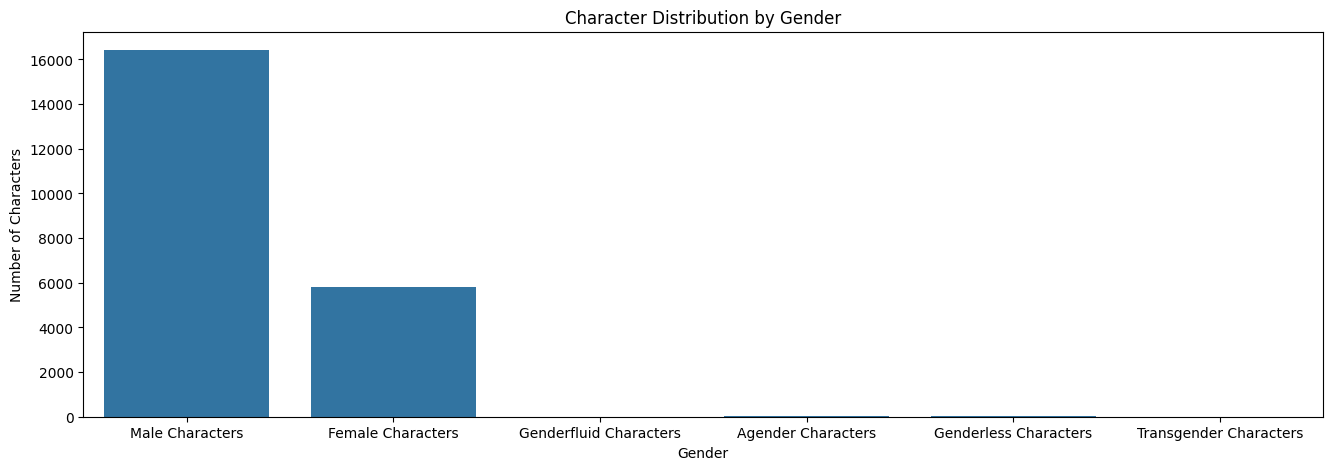

In [21]:
plt.figure(figsize=(16, 5))

sns.countplot(data=characters, x="SEX")

plt.title("Character Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Characters")

plt.show()

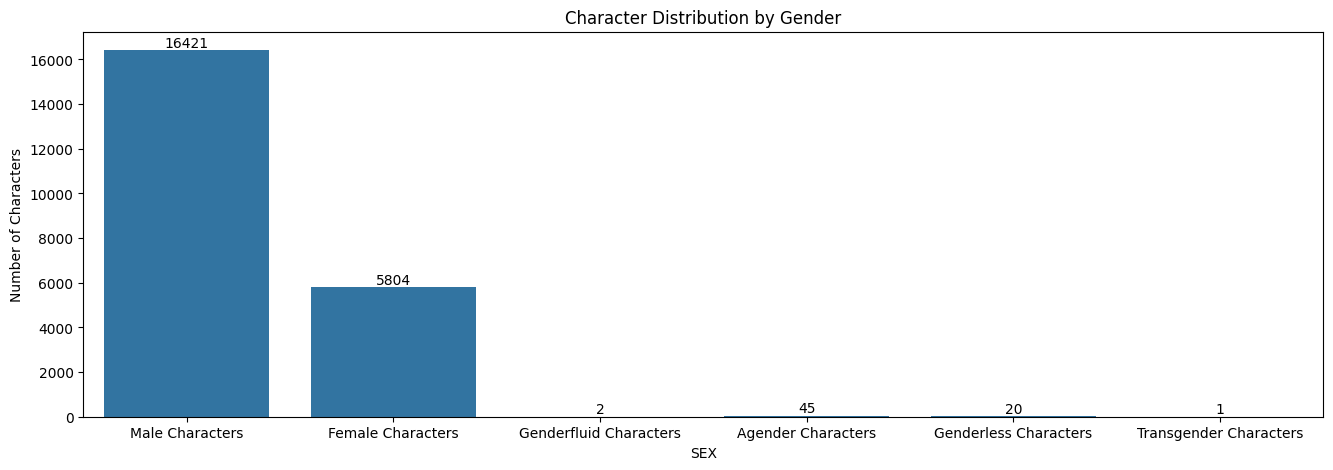

In [22]:
plt.figure(figsize=(16, 5))

ax = sns.countplot(data=characters, x="SEX")

plt.title("Character Distribution by Gender")
plt.xlabel("SEX")
plt.ylabel("Number of Characters")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Finding

The most common gender category in the dataset is Male Characters.

In [23]:
characters["ALIGN"].value_counts()

ALIGN
Bad Characters        9615
Good Characters       7468
Neutral Characters    2773
Reformed Criminals       3
Name: count, dtype: int64

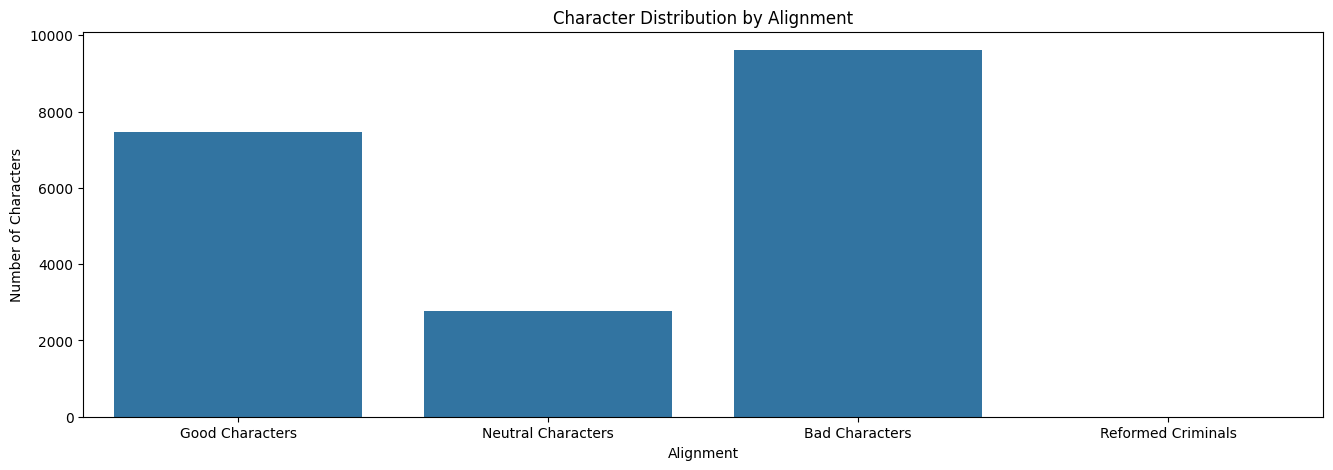

In [24]:
plt.figure(figsize=(16, 5))

sns.countplot(data=characters, x="ALIGN")

plt.title("Character Distribution by Alignment")
plt.xlabel("Alignment")
plt.ylabel("Number of Characters")

plt.show()

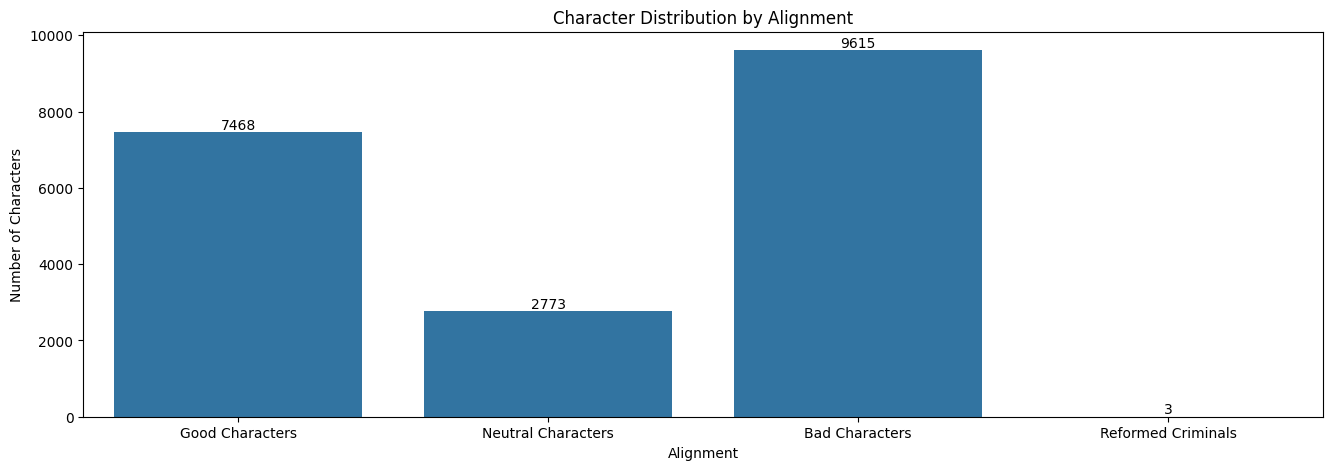

In [25]:
plt.figure(figsize=(16, 5))

ax = sns.countplot(data=characters, x="ALIGN")

plt.title("Character Distribution by Alignment")
plt.xlabel("Alignment")
plt.ylabel("Number of Characters")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Finding

The most common character alignment is Bad Characters.

In [26]:
characters["EYE"].value_counts().head(10)

EYE
Blue Eyes        3064
Brown Eyes       2803
Black Eyes        967
Green Eyes        904
Red Eyes          716
White Eyes        516
Yellow Eyes       342
Grey Eyes         135
Hazel Eyes         99
Variable Eyes      49
Name: count, dtype: int64

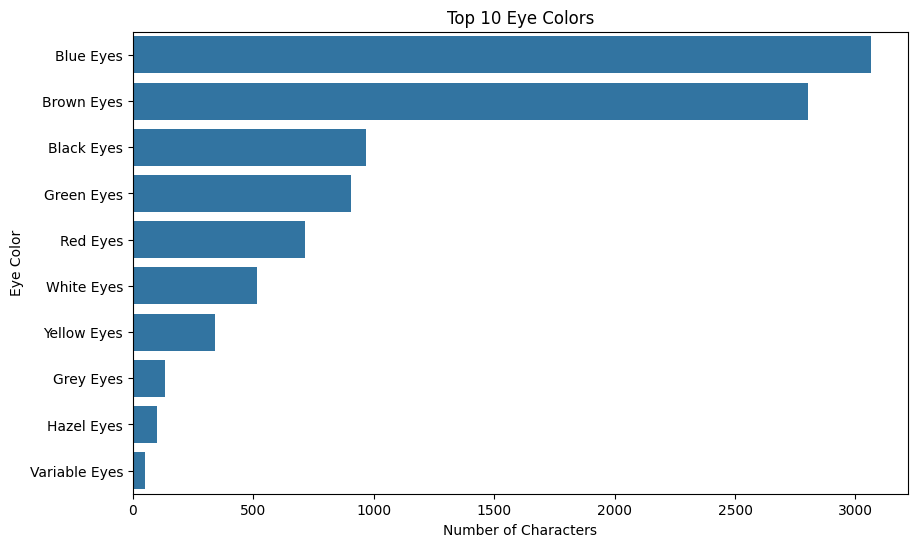

In [27]:
eye_color_counts = characters["EYE"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=eye_color_counts.values,
    y=eye_color_counts.index
)

plt.title("Top 10 Eye Colors")
plt.xlabel("Number of Characters")
plt.ylabel("Eye Color")

plt.show()

Finding:

The most common eye color among the top categories is Blue Eyes.

In [28]:
characters["HAIR"].value_counts().head(10)

HAIR
Black Hair    5329
Brown Hair    3487
Blond Hair    2326
No Hair       1176
White Hair    1100
Red Hair      1081
Bald           838
Grey Hair      688
Green Hair     159
Blue Hair       97
Name: count, dtype: int64

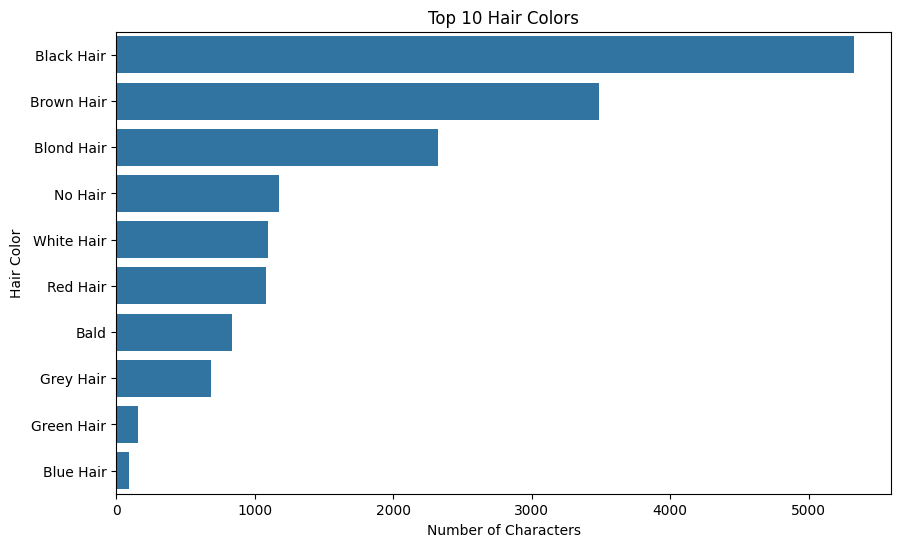

In [29]:
hair_color_counts = characters["HAIR"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=hair_color_counts.values,
    y=hair_color_counts.index
)

plt.title("Top 10 Hair Colors")
plt.xlabel("Number of Characters")
plt.ylabel("Hair Color")

plt.show()

### Finding

The most common hair color among the top categories is Black Hair.

In [30]:
publisher_gender = characters[
    characters["Publisher"].isin(["Marvel", "DC"])
]

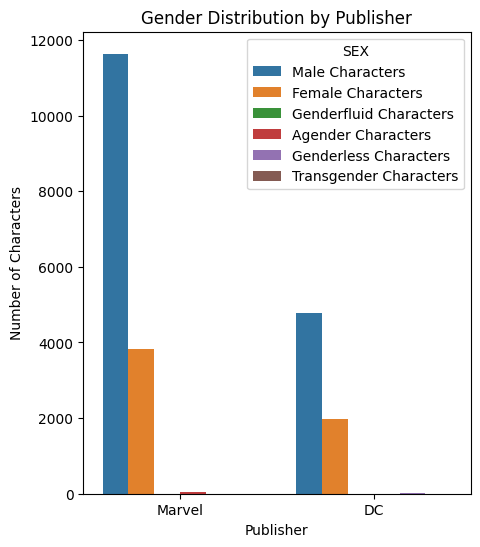

In [31]:
plt.figure(figsize=(5, 6))

sns.countplot(
    data=publisher_gender,
    x="Publisher",
    hue="SEX"
)

plt.title("Gender Distribution by Publisher")
plt.xlabel("Publisher")
plt.ylabel("Number of Characters")

plt.show()

In [32]:
publisher_alignment = characters[
    characters["Publisher"].isin(["Marvel", "DC"])
]

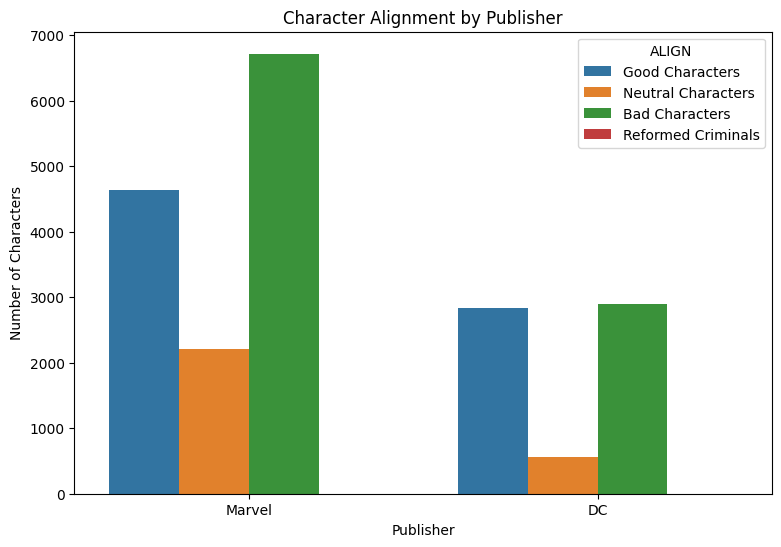

In [33]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=publisher_alignment,
    x="Publisher",
    hue="ALIGN"
)

plt.title("Character Alignment by Publisher")
plt.xlabel("Publisher")
plt.ylabel("Number of Characters")

plt.show()

In [34]:
characters.select_dtypes(include="number").columns

Index(['page_id', 'APPEARANCES', 'Year', 'YEAR'], dtype='object')

In [35]:
characters.describe()

,page_id,APPEARANCES,Year,YEAR
count,23272.000000,21821.000000,15561.000000,6827.000000
mean,254956.821932,19.009303,1984.951803,1989.766662
std,231417.093079,93.814040,19.663571,16.824194
min,1025.000000,1.000000,1939.000000,1935.000000
25%,31385.750000,1.000000,1974.000000,1983.000000
50%,192263.500000,4.000000,1990.000000,1992.000000
75%,456337.750000,10.000000,2000.000000,2003.000000
max,755278.000000,4043.000000,2013.000000,2013.000000


In [36]:
characters.columns

Index(['page_id', 'name', 'urlslug', 'ID', 'ALIGN', 'EYE', 'HAIR', 'SEX',
       'GSM', 'ALIVE', 'APPEARANCES', 'FIRST APPEARANCE', 'Year', 'Publisher',
       'YEAR'],
      dtype='object')

In [37]:
characters["APPEARANCES"].describe()

count    21821.000000
mean        19.009303
std         93.814040
min          1.000000
25%          1.000000
50%          4.000000
75%         10.000000
max       4043.000000
Name: APPEARANCES, dtype: float64

In [38]:
characters.sort_values("APPEARANCES", ascending=False)[
    ["name", "Publisher", "APPEARANCES"]
].head(10)

,name,Publisher,APPEARANCES
0,Spider-Man (Peter Parker),Marvel,4043.0
1,Captain America (Steven Rogers),Marvel,3360.0
16376,Batman (Bruce Wayne),DC,3093.0
2,"Wolverine (James \""Logan\"" Howlett)",Marvel,3061.0
3,"Iron Man (Anthony \""Tony\"" Stark)",Marvel,2961.0
16377,Superman (Clark Kent),DC,2496.0
4,Thor (Thor Odinson),Marvel,2258.0
5,Benjamin Grimm (Earth-616),Marvel,2255.0
6,Reed Richards (Earth-616),Marvel,2072.0
7,Hulk (Robert Bruce Banner),Marvel,2017.0


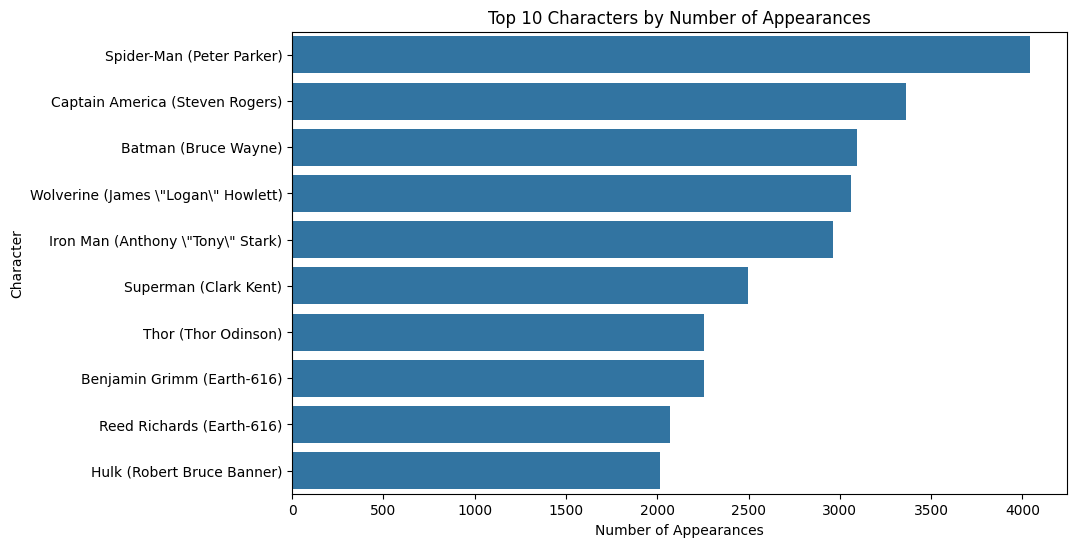

In [39]:
top_characters = characters.sort_values(
    "APPEARANCES",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_characters,
    x="APPEARANCES",
    y="name"
)

plt.title("Top 10 Characters by Number of Appearances")
plt.xlabel("Number of Appearances")
plt.ylabel("Character")

plt.show()

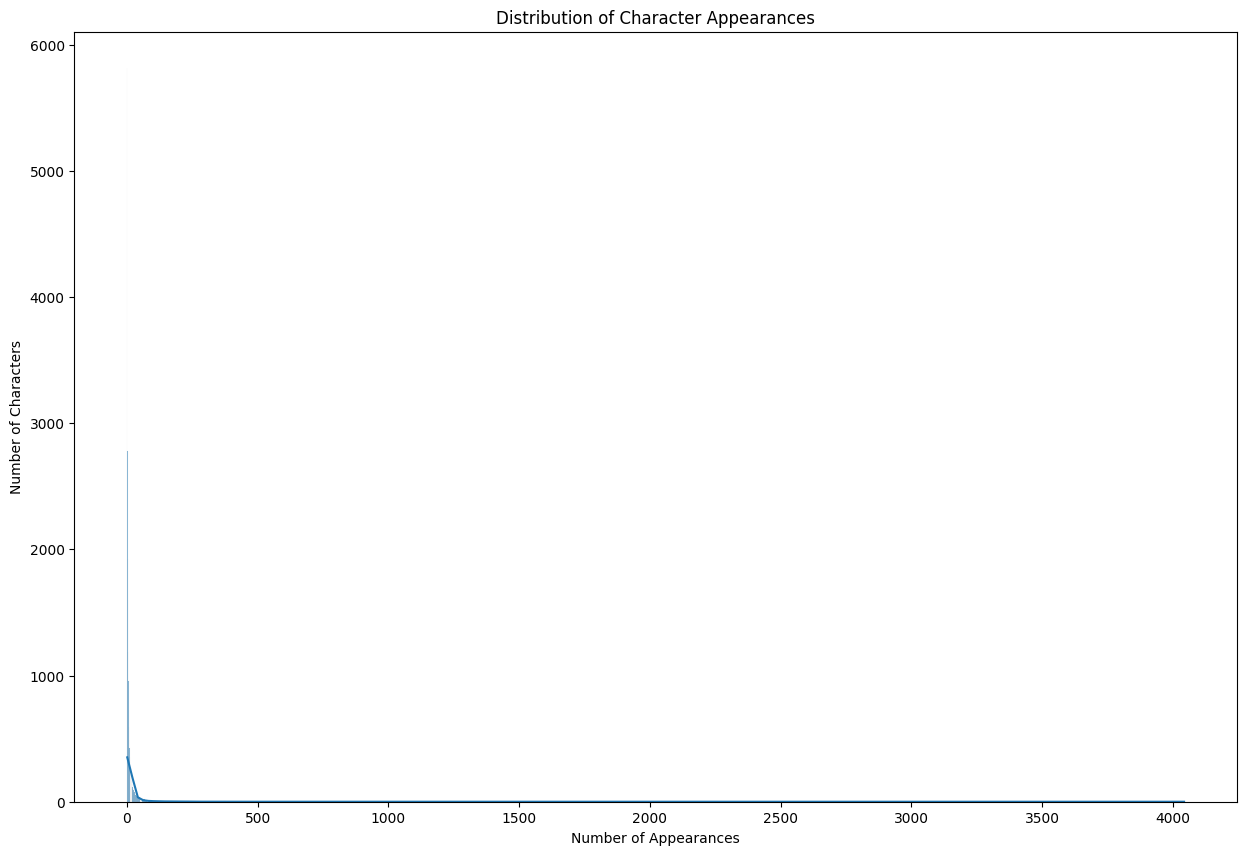

In [40]:
plt.figure(figsize=(15, 10))

sns.histplot(
    data=characters,
    x="APPEARANCES",
    kde=True
)

plt.title("Distribution of Character Appearances")
plt.xlabel("Number of Appearances")
plt.ylabel("Number of Characters")

plt.show()

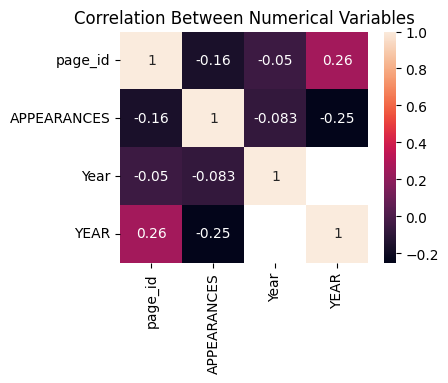

In [41]:
numeric_data = characters.select_dtypes(include="number")

correlation = numeric_data.corr()

plt.figure(figsize=(4, 3))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Between Numerical Variables")

plt.show()

# Key Findings

1. Spider-Man, Batman, Superman, and Wolverine are the most featured characters with the highest number of APPEARANCES.
2. DC and Marvel universes show a significant gender disparity, with male characters outnumbering female characters in the 'SEX' column.
3. The vast majority of characters have Bad (Villains) or Good (Heroes) 'ALIGN' status, with Neutral characters being relatively rare.
4. Blue and Brown are the most common 'EYE' colors, while Black and Brown are the dominant 'HAIR' colors among characters.
5. Character introductions began accelerating significantly from the 1960s onwards, marking the Silver Age of comic books.

# Conclusion

This project analyzed comic book character data using Python, Pandas, Matplotlib, and Seaborn. The analysis explored character characteristics and compared Marvel and DC publishers.

The visualizations helped identify patterns in publisher distribution, gender, alignment, eye color, hair color, and character appearances.

### Summary of Key Insights:
* **Gender Disparity:** Male characters dominate the dataset compared to female characters across both publishers.
* **Alignment Distribution:** Most characters are categorized as either Good or Bad, with Neutral characters being rare.
* **Top Characters:** Iconic heroes like Spider-Man, Batman, and Superman have the highest appearance counts.
* **Character Era:** Character creation peaked after the 1960s (Silver Age of Comics).

Overall, the findings provide a clear understanding of the character demographics and trends represented in comic book history.